In [2]:
# Parameters
param1=1

In [3]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, create_data
from utils import cosine_similarity, get_r_2, vector_angle
from tqdm import tqdm
from tqdm import tqdm


In [4]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [5]:
sigma31_11_PR_data_l = []
cor_lengths = np.unique((np.logspace(1, 2, 50)).astype(int))
for corridor_length in tqdm(cor_lengths):
    C = Config()
    C.num_epochs = 1
    C.length_corridors = [corridor_length]
    X_l = []
    y_l = []
    for max_move in range(1, C.length_corridors[0]):
        C.max_move = max_move

        X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

        X_l.append(X)
        y_l.append(y)

    # sigma11_PR_l = []
    # sigma31_PR_l = []
    sigma31_11_PR_l = []
    # X_PR_l = []
    # y_PR_l = []
    for X,y in zip(X_l, y_l):
        sigma11 = np.sum([xi[:,None]@xi[None,:] for xi, yi in zip(X, y)], 0)
        sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X, y)], 0)

        # lamb_11 = PCA().fit(sigma11).explained_variance_
        # lamb_31 = PCA().fit(sigma31.T).explained_variance_
        lamb_31_11 = PCA().fit(sigma31@np.linalg.pinv(sigma11)).explained_variance_
        # lamb_X = PCA().fit(X).explained_variance_
        # lamb_y = PCA().fit(y).explained_variance_

        # sigma11_PR_l.append(lamb_11.sum() ** 2 / (lamb_11 ** 2).sum())
        # sigma31_PR_l.append(lamb_31.sum() ** 2 / (lamb_31 ** 2).sum())
        sigma31_11_PR_l.append(lamb_31_11.sum() ** 2 / (lamb_31_11 ** 2).sum())
        # X_PR_l.append(lamb_X.sum() ** 2 / (lamb_X ** 2).sum())
        # y_PR_l.append(lamb_y.sum() ** 2 / (lamb_y ** 2).sum())
    sigma31_11_PR_data_l.append(sigma31_11_PR_l)


100%|██████████| 45/45 [28:21<00:00, 37.82s/it] 


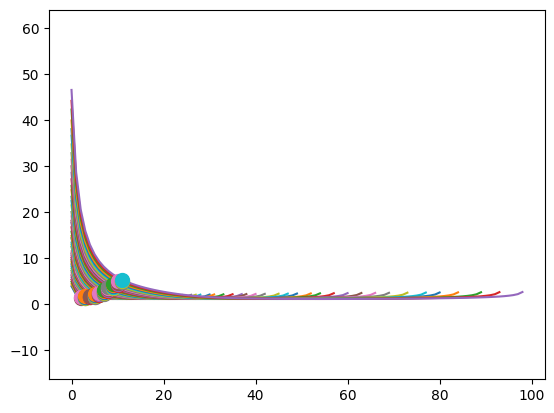

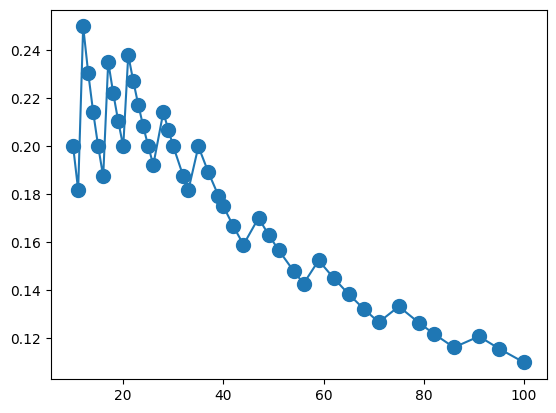

In [6]:
for l, sigma31_11_PR_l in zip(cor_lengths, sigma31_11_PR_data_l):
    plt.plot(sigma31_11_PR_l, label=f'{l}')
from scipy.signal import argrelextrema
from kneed import KneeLocator
knee_x_l = []; knee_y_l = []
for l, sigma31_11_PR_l in zip(cor_lengths, sigma31_11_PR_data_l):
    x = np.arange(len(sigma31_11_PR_l))
    kneedle = KneeLocator(x, sigma31_11_PR_l, S=1.0, curve='convex', direction='decreasing')
    knee_x = kneedle.knee
    knee_y = sigma31_11_PR_l[knee_x]
    plt.plot(knee_x, knee_y, 'o', markersize=10)
    knee_x_l.append(knee_x)
    knee_y_l.append(knee_y)

plt.axis('equal')
plt.show()
plt.plot(cor_lengths, np.array(knee_x_l)/cor_lengths, 'o-', markersize=10)
# plt.axis('equal')

In [ ]:
min_pr_l = [min(pr_l) for pr_l in sigma31_11_PR_data_l]
plt.plot(cor_lengths, min_pr_l, 'o-', markersize=10)
plt.xlabel('Corridor Length')
plt.ylabel('Minimum PR')
plt.show()

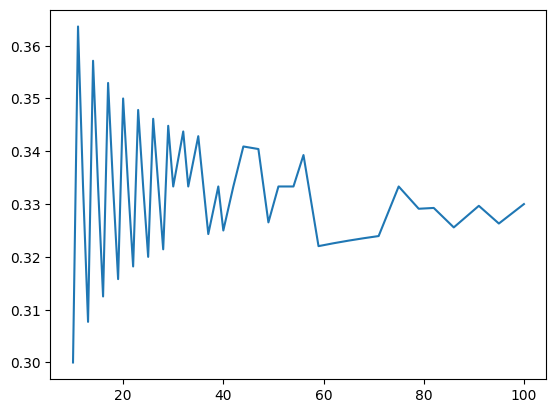

In [7]:
plt.plot(cor_lengths, [(np.where(np.array(l)<1.5)[0][0]+1)/L for L, l in zip(cor_lengths, sigma31_11_PR_data_l)])
# plt.axis('equal')

In [8]:
plt.plot(sigma11_PR_l, label='sigma11')
plt.plot(sigma31_PR_l, label='sigma31')
plt.plot(sigma31_11_PR_l, label='sigma31 @ sigma11^-1')
plt.plot(X_PR_l, label='X')
plt.plot(y_PR_l, label='y')
plt.legend()
plt.show()

NameError: name 'sigma11_PR_l' is not defined

In [ ]:
X = X_l[len(X_l)//2]
y = y_l[len(y_l)//2]
Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X, y)], 0)
Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X], 0)
fig, (ax2) = plt.subplots(1, 1, figsize=(5, 5))
im = ax2.imshow(Sigma31@np.linalg.pinv(Sigma11), cmap='viridis')
plt.colorbar(im, ax=ax2)
ax2.set_title('$\Sigma_{31}\Sigma_{11}^{-1}$', fontsize=50)
ax2.set_xlabel('X dim')
ax2.set_ylabel('y dim')
plt.tight_layout()
plt.show()

In [5]:
X = X_l[len(X_l)//2]
y = y_l[len(y_l)//2]
Sigma = np.corrcoef(X.T, y.T)
import pickle as pkl
with open('Sigma.pkl', 'wb') as f:
    pkl.dump(Sigma, f)
data = np.random.multivariate_normal(np.zeros(Sigma.shape[0]), Sigma, 100000)


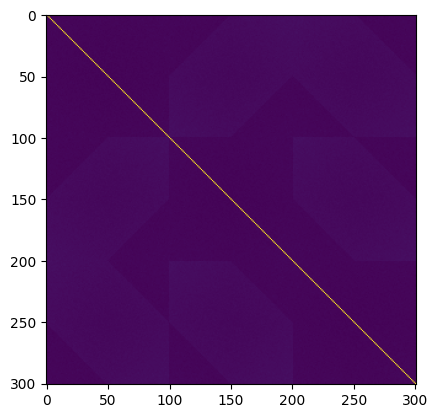

In [6]:
X = data[:,:X.shape[1]]
y = data[:,X.shape[1]:]

plt.imshow(np.corrcoef(X.T, y.T))


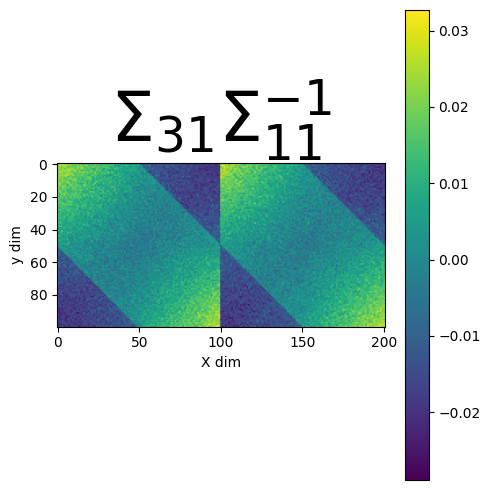

In [7]:

Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X, y)], 0)
Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X], 0)
fig, (ax2) = plt.subplots(1, 1, figsize=(5, 5))
im = ax2.imshow(Sigma31@np.linalg.pinv(Sigma11), cmap='viridis')
plt.colorbar(im, ax=ax2)
ax2.set_title('$\Sigma_{31}\Sigma_{11}^{-1}$', fontsize=50)
ax2.set_xlabel('X dim')
ax2.set_ylabel('y dim')
plt.tight_layout()
plt.show()